# 4_MODEL — Model Training & Artefact Export

Fits QRF, GBM (quantile + conformal), and Similarity on the IHFC reference parquet
using the parameter files produced by `3b_MODEL_SWEEPS`.
Saves trained model files, writes full diagnostic metrics, and bundles everything
into `output/models/model_artefacts.pkl` so that `5_TARGETS` only needs a single load.

**Sections**
1. Configuration & paths
2. Load reference data
3. Train/test split & scaler
4. QRF — fit, save, metrics
5. GBM — fit (quantile + point), conformal calibration, save, metrics
6. Similarity — correction curve, save, metrics
7. Shannon entropy & metric summary
8. Diagnostic plots
9. Bundle & export artefacts for `5_TARGETS`


## 1 · Configuration & paths

In [23]:
import sys, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from scipy.interpolate import PchipInterpolator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from quantile_forest import RandomForestQuantileRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
warnings.filterwarnings('ignore')

# ── user-adjustable ──────────────────────────────────────────────────────
local_data   = Path('data')
param_dir    = Path('output/sweeps')
model_dir    = Path('output/models')
fig_dir      = Path('output/figures/4_MODEL')
TEST_FRAC       = 0.20
RANDOM_SEED     = 42
TARGET_COL      = 'q'
Q_CLIP_MIN      = 0.0
QUANTILES       = [0.05, 0.25, 0.50, 0.75, 0.95]
HIST_BIN_W      = 0.010
CONFORMAL_ALPHA = 0.10
# ── end user section ─────────────────────────────────────────────────────

model_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

with open(param_dir / 'qrf_params.json')      as f: QP = json.load(f)
with open(param_dir / 'gbm_params.json')      as f: GP = json.load(f)
with open(param_dir / 'sim_best_params.json') as f: SP = json.load(f)

from config import obs_model, q_clip_max
print(f'Features  : {len(obs_model)}')
print(f'q_clip_max: {q_clip_max} W/m²')
print(f'Test frac : {TEST_FRAC}')


Features  : 21
q_clip_max: 0.35 W/m²
Test frac : 0.2


## 2 · Load reference data

In [24]:
df = pd.read_parquet(local_data / 'IHFC_obs.parquet')
print(f'Raw rows: {len(df)}')

# clip heat flow, drop rows where any obs_model feature is NaN
df = df[(df[TARGET_COL] >= Q_CLIP_MIN) & (df[TARGET_COL] <= q_clip_max)].copy()
df = df.dropna(subset=obs_model)
print(f'After clip & drop-NaN: {len(df)} rows')

X_all = df[obs_model].values.astype(np.float32)
y_all = df[TARGET_COL].values.astype(np.float32)

if 'weight' in df.columns:
    w_all = df['weight'].values.astype(np.float32)
    w_all = w_all / w_all.mean()
    print(f'Weights loaded  min={w_all.min():.4f}  max={w_all.max():.4f}  mean={w_all.mean():.4f}')
else:
    w_all = np.ones(len(y_all), dtype=np.float32)
    print('WARNING: no weight column found — using uniform weights')

assert np.isfinite(X_all).all(), 'NaNs remain in X_all after dropna — check obs_model'
assert np.isfinite(y_all).all(), 'NaNs remain in y_all'


Raw rows: 30848
After clip & drop-NaN: 30847 rows
Weights loaded  min=0.1123  max=3.5262  mean=1.0000


## 3 · Train/test split & scaler

In [25]:
X_tr_raw, X_te_raw, y_tr, y_te, w_tr, w_te = train_test_split(
    X_all, y_all, w_all, test_size=TEST_FRAC, random_state=RANDOM_SEED)

# Scaler fitted on TRAIN only — no leakage
scaler = StandardScaler().fit(X_tr_raw)
X_tr = scaler.transform(X_tr_raw)
X_te = scaler.transform(X_te_raw)

# σ array for Similarity kernel (per-feature bandwidth on top of StandardScaler)
sigma_arr = np.array([SP['SIM_SIGMAS'].get(f, 1.0) for f in obs_model], dtype=np.float32)

# Conformal calibration slice (taken from end of train — consistent across models)
cal_frac = QP.get('cal_frac', 0.10)
n_cal = int(len(X_tr) * cal_frac)
X_cal, y_cal, w_cal = X_tr[-n_cal:], y_tr[-n_cal:], w_tr[-n_cal:]

print(f'Train: {len(y_tr)}  Test: {len(y_te)}  Cal slice: {n_cal}')
print(f'sigma placeholders: {SP.get("sigma_placeholders", [])}')


Train: 24677  Test: 6170  Cal slice: 2467
sigma placeholders: []


## 4 · Quantile Random Forest

QRF uses the `quantile_forest` library, which stores leaf-node sample
indices so it can return any quantile at prediction time — no need to
re-train for different quantile levels. NaN rows are dropped **before**
fitting (guaranteed by §2 `dropna`); the guard below is a safety check only.


In [26]:
qrf_path = model_dir / 'qrf_model.pkl'
if qrf_path.exists():
    print('QRF: loading saved model')
    with open(qrf_path, 'rb') as f:
        qrf = pickle.load(f)
else:
    print('QRF: training...')
    qrf = RandomForestQuantileRegressor(
        n_estimators     = QP['n_estimators'],
        max_depth        = QP['max_depth'] if QP['max_depth'] != 'None' else None,
        min_samples_leaf = QP['min_samples_leaf'],
        max_features     = QP['max_features'],
        n_jobs           = -1,
        random_state     = RANDOM_SEED,
    )
    # Safety guard — should be zero after §2 dropna
    nan_rows = ~np.isfinite(X_tr).all(axis=1)
    if nan_rows.any():
        print(f'  WARNING: dropping {nan_rows.sum()} NaN rows from X_tr before QRF fit')
        X_fit, y_fit, w_fit = X_tr[~nan_rows], y_tr[~nan_rows], w_tr[~nan_rows]
    else:
        X_fit, y_fit, w_fit = X_tr, y_tr, w_tr
    qrf.fit(X_fit, y_fit, sample_weight=w_fit)
    with open(qrf_path, 'wb') as f:
        pickle.dump(qrf, f)
    print(f'QRF saved → {qrf_path}')

# ── test-set predictions ─────────────────────────────────────────────────
QUANTILES_DENSE = np.linspace(0.02, 0.98, 49).tolist()
qrf_preds = qrf.predict(X_te, quantiles=QUANTILES)        # (n, 5)
qrf_dense = qrf.predict(X_te, quantiles=QUANTILES_DENSE)  # (n, 49)
qrf_q50   = qrf_preds[:, QUANTILES.index(0.50)]
qrf_mean  = qrf_dense.mean(axis=1)
qrf_std   = qrf_dense.std(axis=1)

# ── conformal calibration ────────────────────────────────────────────────
cal_preds   = qrf.predict(X_cal, quantiles=[0.05, 0.95])  # (n_cal, 2)
cal_q05_qrf = cal_preds[:, 0]
cal_q95_qrf = cal_preds[:, 1]
scores_qrf  = np.maximum(cal_q05_qrf - y_cal, y_cal - cal_q95_qrf)
qhat_qrf    = np.quantile(scores_qrf, (1 - CONFORMAL_ALPHA) * (1 + 1 / len(scores_qrf)))
qrf_conf_lo = qrf_preds[:, 0]  - qhat_qrf
qrf_conf_hi = qrf_preds[:, -1] + qhat_qrf
qrf_picp_conf = np.mean((y_te >= qrf_conf_lo) & (y_te <= qrf_conf_hi))

# ── metrics ──────────────────────────────────────────────────────────────
qrf_r2      = r2_score(y_te, qrf_q50)
qrf_rmse    = np.sqrt(mean_squared_error(y_te, qrf_q50))
qrf_mae     = mean_absolute_error(y_te, qrf_q50)
qrf_pi90_w  = np.mean(qrf_preds[:, -1] - qrf_preds[:, 0])
qrf_picp_raw = np.mean((y_te >= qrf_preds[:, 0]) & (y_te <= qrf_preds[:, -1]))
print(f'QRF  R²={qrf_r2:.4f}  RMSE={qrf_rmse*1000:.2f} mW/m²  MAE={qrf_mae*1000:.2f}'
      f'  PI90_cov={qrf_picp_raw:.3f}  Conformal_cov={qrf_picp_conf:.3f}')


QRF: loading saved model
QRF  R²=0.6215  RMSE=27.63 mW/m²  MAE=11.42  PI90_cov=0.965  Conformal_cov=0.895


## 5 · Gradient Boosting Regression

Three separate `HistGradientBoostingRegressor` models are trained at
quantile losses Q05 / Q50 / Q95. `HistGBM` handles NaNs natively.
Conformal calibration is applied post-hoc to produce coverage-guaranteed
prediction intervals without extra training runs.


In [27]:
gbm_paths = {q: model_dir / f'gbm_q{int(q*100):02d}_model.pkl'
             for q in GP['quantile_losses']}

gbm_models = {}
for q, path in gbm_paths.items():
    if path.exists():
        print(f'GBM Q{int(q*100):02d}: loading saved model')
        with open(path, 'rb') as f:
            gbm_models[q] = pickle.load(f)
    else:
        print(f'GBM Q{int(q*100):02d}: training...')
        params = dict(
            loss             = 'quantile' if q != 0.5 else 'squared_error',
            quantile         = q if q != 0.5 else None,
            max_iter         = GP['max_iter'],
            max_depth        = GP['max_depth'],
            learning_rate    = GP['learning_rate'],
            min_samples_leaf = GP['min_samples_leaf'],
            max_features     = GP['max_features'],
            l2_regularization= GP['l2_regularization'],
            random_state     = RANDOM_SEED,
        )
        if q == 0.5:
            params.pop('quantile')
        gbm_models[q] = HistGradientBoostingRegressor(**params).fit(
            X_tr, y_tr, sample_weight=w_tr)
        with open(path, 'wb') as f:
            pickle.dump(gbm_models[q], f)
        print(f'  saved → {path}')

# ── test-set predictions ─────────────────────────────────────────────────
gbm_q05 = gbm_models[0.05].predict(X_te)
gbm_q50 = gbm_models[0.50].predict(X_te)
gbm_q95 = gbm_models[0.95].predict(X_te)

# ── conformal calibration ────────────────────────────────────────────────
cal_05_gbm  = gbm_models[0.05].predict(X_cal)
cal_95_gbm  = gbm_models[0.95].predict(X_cal)
scores_gbm  = np.maximum(cal_05_gbm - y_cal, y_cal - cal_95_gbm)
qhat_gbm    = np.quantile(scores_gbm, (1 - CONFORMAL_ALPHA) * (1 + 1 / len(scores_gbm)))
gbm_conf_lo = gbm_q05 - qhat_gbm
gbm_conf_hi = gbm_q95 + qhat_gbm
gbm_picp_conf = np.mean((y_te >= gbm_conf_lo) & (y_te <= gbm_conf_hi))

# ── metrics ──────────────────────────────────────────────────────────────
gbm_r2      = r2_score(y_te, gbm_q50)
gbm_rmse    = np.sqrt(mean_squared_error(y_te, gbm_q50))
gbm_mae     = mean_absolute_error(y_te, gbm_q50)
gbm_pi90_w  = np.mean(gbm_q95 - gbm_q05)
gbm_picp_raw = np.mean((y_te >= gbm_q05) & (y_te <= gbm_q95))
print(f'GBM  R²={gbm_r2:.4f}  RMSE={gbm_rmse*1000:.2f} mW/m²  MAE={gbm_mae*1000:.2f}'
      f'  PI90_cov={gbm_picp_raw:.3f}  Conformal_cov={gbm_picp_conf:.3f}')


GBM Q05: training...
  saved → output/models/gbm_q05_model.pkl
GBM Q50: training...
  saved → output/models/gbm_q50_model.pkl
GBM Q95: training...
  saved → output/models/gbm_q95_model.pkl
GBM  R²=0.3276  RMSE=36.83 mW/m²  MAE=21.03  PI90_cov=0.887  Conformal_cov=0.884


## 6 · Similarity — correction curve

The kernel-weighted mean is biased toward the centre of the reference
heat-flow distribution (regression dilution). A monotone PCHIP spline
fitted on **train-set** percentiles maps predicted values back onto the
empirical reference distribution — stretching the predicted spread to
match the observed range. Fitted on train only; no test leakage.


In [52]:
def apply_correction_spline(vals, spline):
    out = np.full_like(vals, np.nan, dtype=np.float32)
    ok  = np.isfinite(vals)
    out[ok] = spline(vals[ok]).astype(np.float32)
    return out


qrf_cal_preds = qrf.predict(X_cal, quantiles=[0.50])  # (n_cal,)
if qrf_cal_preds.ndim == 2:
    qrf_cal_q50 = qrf_cal_preds[:, 0]
else:
    qrf_cal_q50 = qrf_cal_preds

pred_pctls_qrf = weighted_percentile(qrf_cal_q50, w_cal, pctls)
true_pctls_qrf = weighted_percentile(y_cal,        w_cal, pctls)
_, keep = np.unique(pred_pctls_qrf, return_index=True)
qrf_correction_spline = PchipInterpolator(
    pred_pctls_qrf[keep], true_pctls_qrf[keep], extrapolate=True)

qrf_q50_corr = apply_correction_spline(qrf_q50, qrf_correction_spline)

# ── GBM distribution correction ──────────────────────────────────────────
gbm_cal_q50 = gbm_models[0.50].predict(X_cal)

pred_pctls_gbm = weighted_percentile(gbm_cal_q50, w_cal, pctls)
true_pctls_gbm = weighted_percentile(y_cal,        w_cal, pctls)
_, keep = np.unique(pred_pctls_gbm, return_index=True)
gbm_correction_spline = PchipInterpolator(
    pred_pctls_gbm[keep], true_pctls_gbm[keep], extrapolate=True)

gbm_q50_corr = apply_correction_spline(gbm_q50, gbm_correction_spline)

qrf_q05_corr = apply_correction_spline(qrf_preds[:, 0],  qrf_correction_spline)
qrf_q95_corr = apply_correction_spline(qrf_preds[:, -1], qrf_correction_spline)

In [51]:
def similarity_predict(X_ref, y_ref, w_ref, X_target, sigma_arr, K, batch=512):
    """Batched similarity kernel.

    X_ref / X_target: StandardScaler-normalised arrays.
    sigma_arr: per-feature bandwidth (applied once inside here).
    NaN rows in X_target returned as NaN in all outputs.
    Returns (n_target, 4): [q_mean, q_median, q_std, N_eff]
    """
    sort_idx = np.argsort(y_ref)
    y_s      = y_ref[sort_idx]
    results  = np.full((len(X_target), 4), np.nan, dtype=np.float64)

    for i in range(0, len(X_target), batch):
        Xb    = X_target[i:i+batch]
        valid = ~np.isnan(Xb).any(axis=1)
        if not valid.any():
            continue
        Xv   = Xb[valid]
        diff = (Xv[:, None, :] - X_ref[None, :, :]) / sigma_arr
        S    = np.exp(-0.5 * np.nanmean(diff**2, axis=2))
        S_K  = S ** K
        if w_ref is not None:
            S_K = S_K * w_ref[None, :]
        denom = S_K.sum(axis=1, keepdims=True)
        ok    = denom[:, 0] > 1e-30
        w     = np.where(ok[:, None], S_K / (denom + 1e-30), np.nan)

        q_mean = np.nansum(w * y_ref, axis=1)
        q_std  = np.sqrt(np.nansum(w * (y_ref - q_mean[:, None])**2, axis=1))
        w_s    = w[:, sort_idx]
        cumw   = np.nancumsum(w_s, axis=1)
        tot    = cumw[:, -1]
        med_idx = np.argmax(cumw >= (tot[:, None] * 0.5), axis=1)
        q_med  = y_s[med_idx]
        N_eff  = 1.0 / np.nansum(w**2, axis=1)

        out = np.column_stack([q_mean, q_med, q_std, N_eff])
        out[~ok] = np.nan
        results[i:i+batch][valid] = out
    return results


def weighted_percentile(vals, weights, pcts):
    """Weighted quantile via sorted cumulative weights. Ignores NaNs."""
    mask = np.isfinite(vals) & np.isfinite(weights)
    vs, ws = vals[mask], weights[mask]
    idx  = np.argsort(vs)
    cumw = np.cumsum(ws[idx]) / ws.sum()
    return np.interp(pcts / 100.0, cumw, vs[idx])


K = SP['SIM_BEST_K']
print('Computing Similarity on test set...')
sim_te = similarity_predict(X_tr, y_tr, w_tr, X_te, sigma_arr, K)
sim_q_mean, sim_q_med, sim_q_std, sim_N_eff = sim_te.T
print(f'  NaN fraction in sim_q_mean: {np.isnan(sim_q_mean).mean():.3%}')

# ── correction spline (train self-prediction — leave-in, intentional) ────
print('Fitting correction spline on train predictions...')
sim_tr_out  = similarity_predict(X_tr, y_tr, w_tr, X_tr, sigma_arr, K)
sim_tr_mean = sim_tr_out[:, 0]

pctls      = np.linspace(1, 99, 200)
pred_pctls = weighted_percentile(sim_tr_mean, w_tr, pctls)
true_pctls = weighted_percentile(y_tr,        w_tr, pctls)

_, keep = np.unique(pred_pctls, return_index=True)
correction_spline = PchipInterpolator(pred_pctls[keep], true_pctls[keep], extrapolate=True)


sim_q_mean_corr = apply_correction_spline(sim_q_mean, correction_spline)
sim_q_med_corr  = apply_correction_spline(sim_q_med, correction_spline)

# ── metrics ──────────────────────────────────────────────────────────────
valid_te    = np.isfinite(sim_q_mean_corr) & np.isfinite(y_te)
sim_r2_raw  = r2_score(y_te[valid_te], sim_q_mean[valid_te])
sim_r2_corr = r2_score(y_te[valid_te], sim_q_mean_corr[valid_te])
sim_rmse    = np.sqrt(mean_squared_error(y_te[valid_te], sim_q_mean_corr[valid_te]))
sim_mae     = mean_absolute_error(y_te[valid_te], sim_q_mean_corr[valid_te])
print(f'SIM  R²(raw)={sim_r2_raw:.4f}  R²(corr)={sim_r2_corr:.4f}'
      f'  RMSE={sim_rmse*1000:.2f} mW/m²  MAE={sim_mae*1000:.2f} mW/m² K={K}')


# Computing Similarity on test set...
#   NaN fraction in sim_q_mean: 0.016%
# Fitting correction spline on train predictions...
# SIM  R²(raw)=0.3656  R²(corr)=0.2956  RMSE=37.70 mW/m²  MAE=19.45 mW/m² K=13.897435897435898

Computing Similarity on test set...
  NaN fraction in sim_q_mean: 0.016%
Fitting correction spline on train predictions...
SIM  R²(raw)=0.3656  R²(corr)=0.2956  RMSE=37.70 mW/m²  MAE=19.45 mW/m² K=13.897435897435898


## 7 · Shannon entropy & metric summary

In [29]:
from scipy.stats import entropy as scipy_entropy

def empirical_entropy(vals, bin_width=HIST_BIN_W):
    """Shannon entropy (nats) of an empirical distribution."""
    bins   = np.arange(Q_CLIP_MIN, q_clip_max + bin_width, bin_width)
    counts, _ = np.histogram(vals[np.isfinite(vals)], bins=bins)
    probs  = counts / counts.sum()
    return scipy_entropy(probs[probs > 0])

def mean_bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

H_obs = empirical_entropy(y_te)
H_qrf = empirical_entropy(qrf_q50)
H_gbm = empirical_entropy(gbm_q50)
H_sim = empirical_entropy(sim_q_mean_corr)

metrics = pd.DataFrame({
    'Method'         : ['QRF (Q50)', 'GBM (Q50)', 'Similarity (corrected)'],
    'R²'             : [qrf_r2,  gbm_r2,  sim_r2_corr],
    'RMSE [mW/m²]'   : [qrf_rmse*1e3,  gbm_rmse*1e3,  sim_rmse*1e3],
    'MAE [mW/m²]'    : [qrf_mae*1e3,   gbm_mae*1e3,   sim_mae*1e3],
    'Bias [mW/m²]'   : [mean_bias(y_te, qrf_q50)*1e3,
                         mean_bias(y_te, gbm_q50)*1e3,
                         mean_bias(y_te[valid_te], sim_q_mean_corr[valid_te])*1e3],
    'PI90 coverage'  : [qrf_picp_conf, gbm_picp_conf, np.nan],
    'PI90 width [mW]': [qrf_pi90_w*1e3, gbm_pi90_w*1e3, np.nan],
    'Shannon H [nat]': [H_qrf, H_gbm, H_sim],
})
metrics = metrics.round(3)
print(metrics.to_string(index=False))
metrics.to_csv(model_dir / 'model_metrics.csv', index=False)
print(f'\nObserved entropy: {H_obs:.3f} nat')
print(f'Metrics saved → {model_dir / "model_metrics.csv"}')


                Method    R²  RMSE [mW/m²]  MAE [mW/m²]  Bias [mW/m²]  PI90 coverage  PI90 width [mW]  Shannon H [nat]
             QRF (Q50) 0.621        27.632       11.420        -2.870          0.895           71.211            2.218
             GBM (Q50) 0.328        36.828       21.027        -0.049          0.884           83.318            1.964
Similarity (corrected) 0.296        37.696       19.449        -0.512            NaN              NaN            2.430

Observed entropy: 2.463 nat
Metrics saved → output/models/model_metrics.csv


## 8 · Diagnostic plots

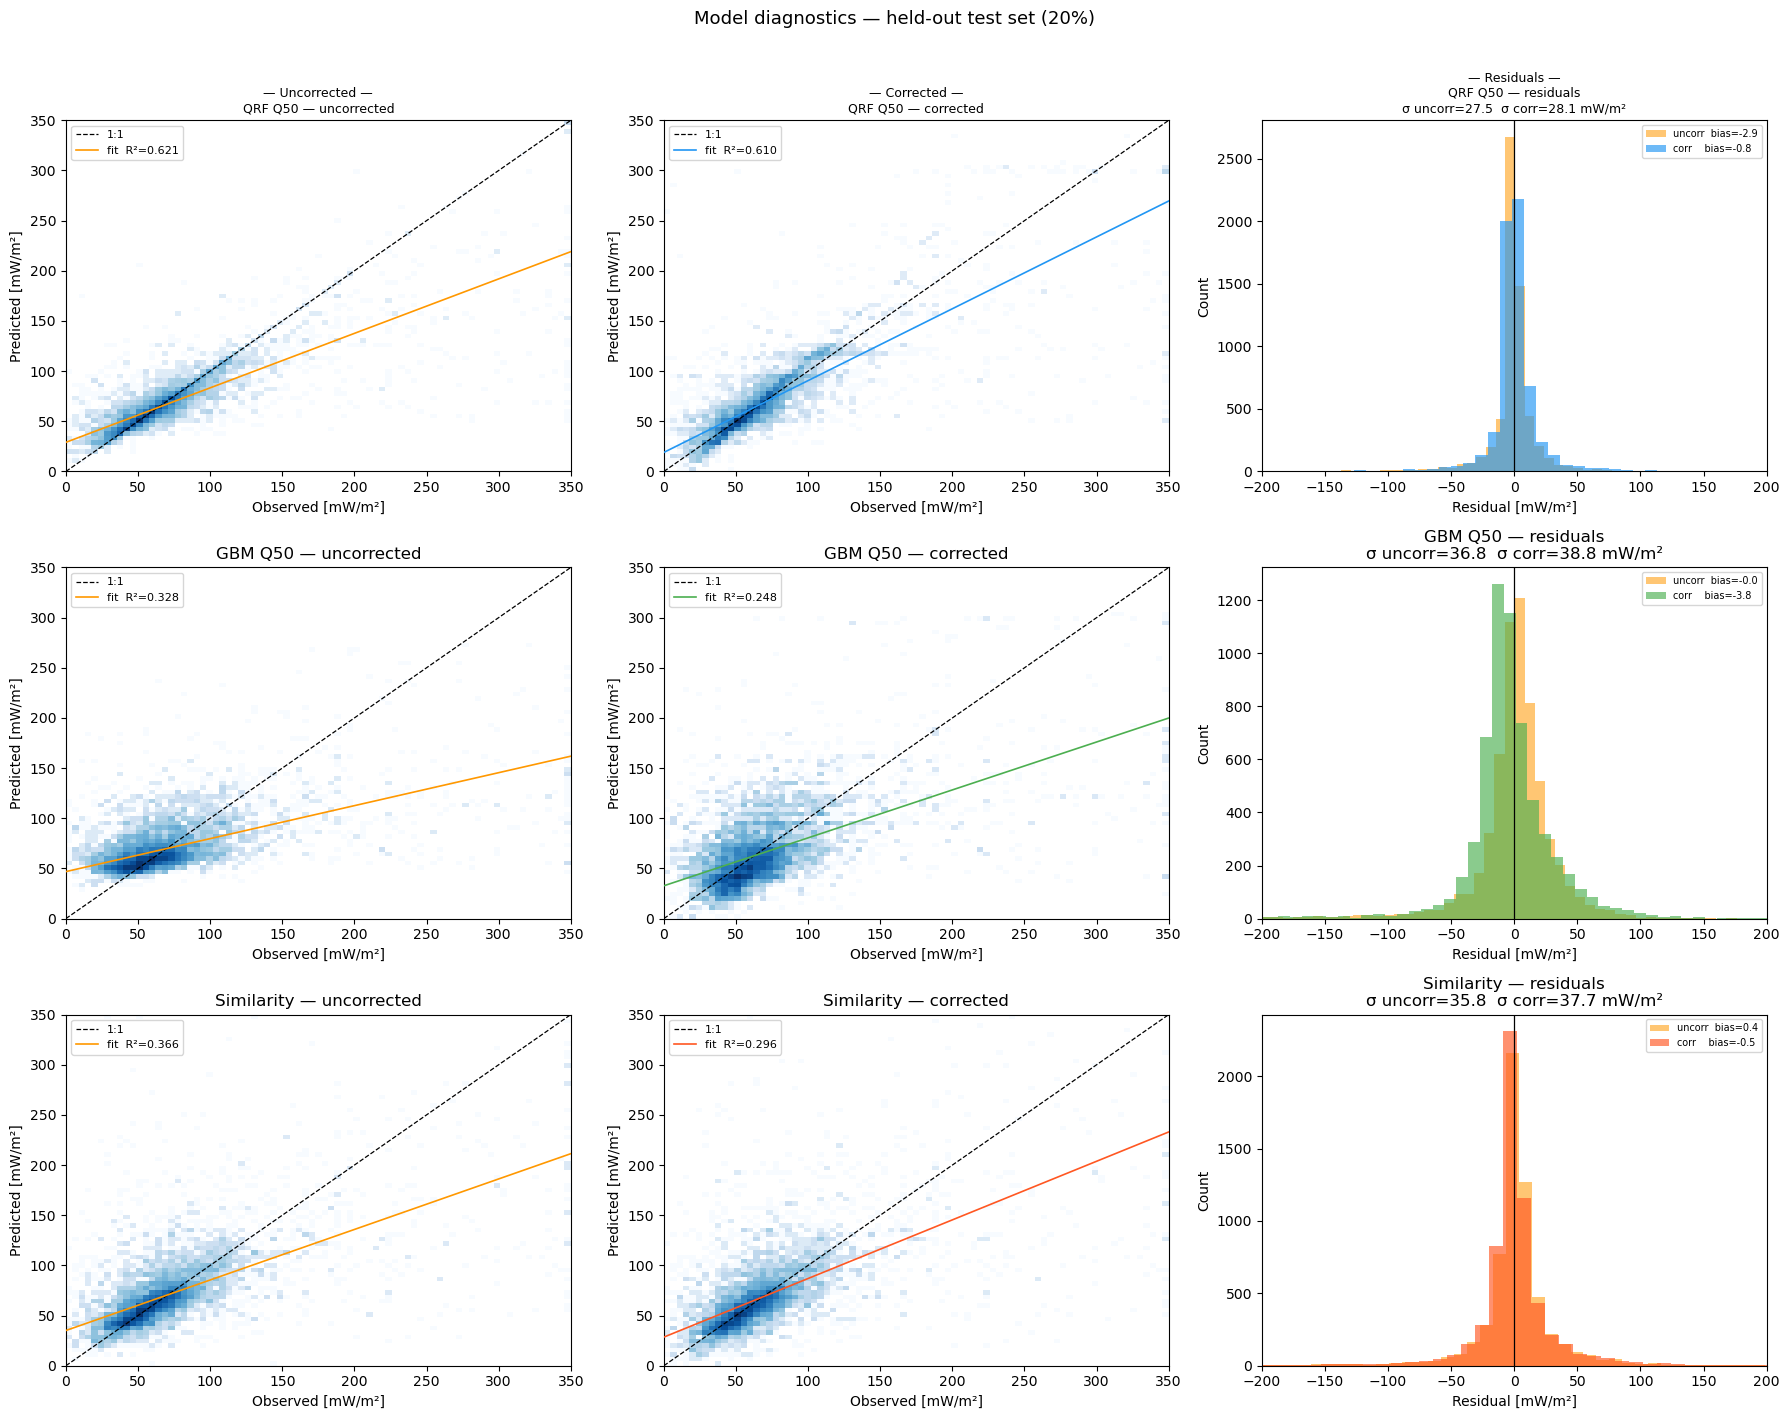

Figure saved → output/figures/4_MODEL/scatter_residuals.png


In [54]:
def scatter_panel(ax_scat, ax_res, y_true, y_pred, label, color):
    lim = (Q_CLIP_MIN * 1e3, q_clip_max * 1e3)
    yt, yp = y_true * 1e3, y_pred * 1e3
    bins = np.linspace(lim[0], lim[1], 80)
    h, xe, ye = np.histogram2d(yt, yp, bins=bins)
    h = np.ma.masked_where(h == 0, h)
    ax_scat.pcolormesh(xe, ye, h.T, cmap='Blues',
                       norm=plt.matplotlib.colors.LogNorm(),
                       rasterized=True, zorder=0)
    ax_scat.plot(lim, lim, 'k--', lw=0.9, zorder=2, label='1:1')
    r2 = r2_score(y_true, y_pred)
    m, b = np.polyfit(yt, yp, 1)
    xfit = np.array(lim)
    ax_scat.plot(xfit, m*xfit + b, color=color, lw=1.2, zorder=3,
                 label=f'fit  R²={r2:.3f}')
    ax_scat.set_xlim(lim); ax_scat.set_ylim(lim)
    ax_scat.set_xlabel('Observed [mW/m²]')
    ax_scat.set_ylabel('Predicted [mW/m²]')
    ax_scat.set_title(label)
    ax_scat.legend(fontsize=8, loc='upper left')
    resid = yp - yt
    ax_res.hist(resid, bins=60, color=color, alpha=0.75, edgecolor='none')
    ax_res.axvline(0, color='k', lw=0.9)
    ax_res.set_xlabel('Residual [mW/m²]')
    ax_res.set_ylabel('Count')
    ax_res.set_title(f'Bias={np.mean(resid):.2f}  σ={np.std(resid):.2f} mW/m²')
    ax_res.set_xlim(-200, 200)


def corr_panel(ax, y_true, y_pred_raw, y_pred_corr, label, color):
    """Overlay uncorrected (faint) and corrected (solid) on the same scatter."""
    lim = (Q_CLIP_MIN * 1e3, q_clip_max * 1e3)
    yt   = y_true     * 1e3
    yp_r = y_pred_raw  * 1e3
    yp_c = y_pred_corr * 1e3
    bins = np.linspace(lim[0], lim[1], 80)

    # uncorrected — faint orange heatmap
    h_r, xe, ye = np.histogram2d(yt, yp_r, bins=bins)
    h_r = np.ma.masked_where(h_r == 0, h_r)
    ax.pcolormesh(xe, ye, h_r.T, cmap='Oranges',
                  norm=plt.matplotlib.colors.LogNorm(),
                  rasterized=True, zorder=0, alpha=0.45)

    # corrected — solid blue heatmap
    h_c, xe, ye = np.histogram2d(yt, yp_c, bins=bins)
    h_c = np.ma.masked_where(h_c == 0, h_c)
    ax.pcolormesh(xe, ye, h_c.T, cmap='Blues',
                  norm=plt.matplotlib.colors.LogNorm(),
                  rasterized=True, zorder=1, alpha=0.75)

    ax.plot(lim, lim, 'k--', lw=0.9, zorder=3, label='1:1')
    r2_r = r2_score(y_true, y_pred_raw)
    r2_c = r2_score(y_true, y_pred_corr)
    ax.plot([], [], color='#FF9800', lw=2, label=f'uncorr  R²={r2_r:.3f}')
    ax.plot([], [], color=color,     lw=2, label=f'corr    R²={r2_c:.3f}')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Observed [mW/m²]')
    ax.set_ylabel('Predicted [mW/m²]')
    ax.set_title(f'{label} — correction')
    ax.legend(fontsize=8, loc='upper left')


# ── build figure: 3 rows × 3 columns ────────────────────────────────────
#   col 0: uncorrected scatter   col 1: corrected scatter   col 2: residuals
sim_valid = np.isfinite(sim_q_mean_corr) & np.isfinite(y_te)

rows = [
    # (y_true,            y_raw,      y_corr,             label,        color)
    (y_te,                qrf_q50,    qrf_q50_corr,       'QRF Q50',          '#2196F3'),
    (y_te,                gbm_q50,    gbm_q50_corr,       'GBM Q50',          '#4CAF50'),
    (y_te[sim_valid],     sim_q_mean[sim_valid],
                          sim_q_mean_corr[sim_valid],     'Similarity',       '#FF5722'),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, (yt, yraw, ycorr, label, color) in enumerate(rows):
    scatter_panel(axes[i, 0], axes[i, 2], yt, yraw,  f'{label} — uncorrected', '#FF9800')
    scatter_panel(axes[i, 1], axes[i, 2], yt, ycorr, f'{label} — corrected',   color)
    # overlay residual histograms on the same ax (col 2 already drawn twice above,
    # so re-draw cleanly):
    axes[i, 2].cla()
    resid_raw  = (yraw  - yt) * 1e3
    resid_corr = (ycorr - yt) * 1e3
    axes[i, 2].hist(resid_raw,  bins=60, color='#FF9800', alpha=0.55,
                    edgecolor='none', label=f'uncorr  bias={np.mean(resid_raw):.1f}')
    axes[i, 2].hist(resid_corr, bins=60, color=color,     alpha=0.65,
                    edgecolor='none', label=f'corr    bias={np.mean(resid_corr):.1f}')
    axes[i, 2].axvline(0, color='k', lw=0.9)
    axes[i, 2].set_xlabel('Residual [mW/m²]')
    axes[i, 2].set_ylabel('Count')
    axes[i, 2].set_title(f'{label} — residuals\n'
                          f'σ uncorr={np.std(resid_raw):.1f}  '
                          f'σ corr={np.std(resid_corr):.1f} mW/m²')
    axes[i, 2].set_xlim(-200, 200)
    axes[i, 2].legend(fontsize=7)

# column headers
for ax, title in zip(axes[0], ['Uncorrected', 'Corrected', 'Residuals']):
    ax.set_title(f'— {title} —\n' + ax.get_title(), fontsize=9)

fig.suptitle('Model diagnostics — held-out test set (20%)', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(fig_dir / 'scatter_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {fig_dir / "scatter_residuals.png"}')

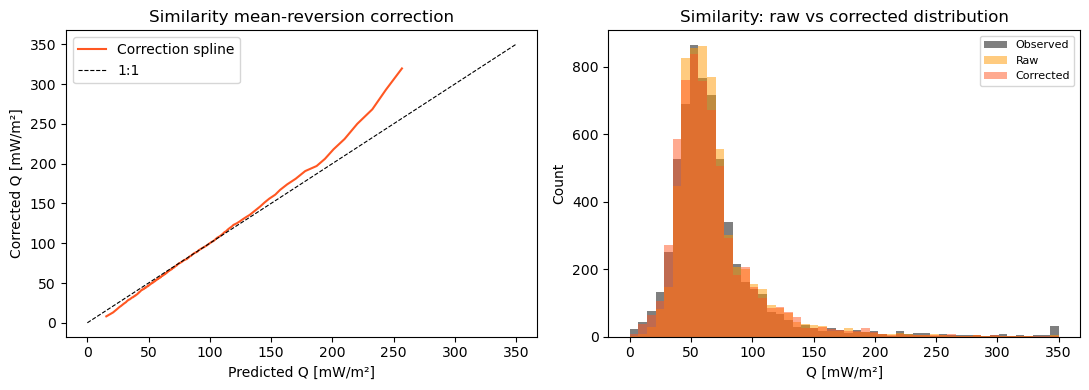

Figure saved → output/figures/4_MODEL/similarity_correction.png


In [55]:
# ── Similarity correction-curve visualisation ────────────────────────────
fig2, ax2 = plt.subplots(1, 2, figsize=(11, 4))

ax2[0].plot(pred_pctls * 1e3, true_pctls * 1e3, color='#FF5722', lw=1.5,
            label='Correction spline')
ax2[0].plot([0, q_clip_max*1e3], [0, q_clip_max*1e3], 'k--', lw=0.8, label='1:1')
ax2[0].set_xlabel('Predicted Q [mW/m²]')
ax2[0].set_ylabel('Corrected Q [mW/m²]')
ax2[0].set_title('Similarity mean-reversion correction')
ax2[0].legend()

bins50 = np.linspace(0, q_clip_max * 1e3, 51)
ax2[1].hist(y_te * 1e3,               bins=bins50, alpha=0.5, label='Observed',  color='k')
ax2[1].hist(sim_q_mean[sim_valid]*1e3, bins=bins50, alpha=0.5, label='Raw',       color='#FF9800')
ax2[1].hist(sim_q_mean_corr[sim_valid]*1e3, bins=bins50, alpha=0.5,
            label='Corrected', color='#FF5722')
ax2[1].set_xlabel('Q [mW/m²]')
ax2[1].set_ylabel('Count')
ax2[1].set_title('Similarity: raw vs corrected distribution')
ax2[1].legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(fig_dir / 'similarity_correction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {fig_dir / "similarity_correction.png"}')


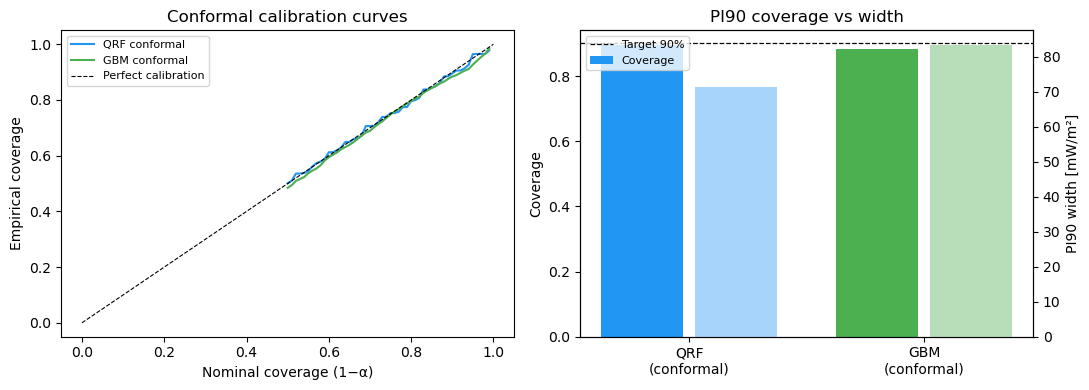

Figure saved → output/figures/4_MODEL/pi_calibration.png


In [32]:
# ── PI coverage calibration plot ─────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4))

alpha_grid  = np.linspace(0.01, 0.50, 50)
cov_qrf_raw  = [np.mean((y_te >= qrf_preds[:, 0]) & (y_te <= qrf_preds[:, -1]))] * len(alpha_grid)
cov_gbm_raw  = [np.mean((y_te >= gbm_q05) & (y_te <= gbm_q95))] * len(alpha_grid)

cov_qrf_conf, cov_gbm_conf = [], []
for alpha in alpha_grid:
    q_q = np.quantile(scores_qrf, (1-alpha)*(1+1/len(scores_qrf)))
    cov_qrf_conf.append(np.mean((y_te >= qrf_preds[:, 0]-q_q) & (y_te <= qrf_preds[:, -1]+q_q)))
    q_g = np.quantile(scores_gbm, (1-alpha)*(1+1/len(scores_gbm)))
    cov_gbm_conf.append(np.mean((y_te >= gbm_q05-q_g) & (y_te <= gbm_q95+q_g)))

axes3[0].plot(1-alpha_grid, cov_qrf_conf, color='#2196F3', lw=1.5, label='QRF conformal')
axes3[0].plot(1-alpha_grid, cov_gbm_conf, color='#4CAF50', lw=1.5, label='GBM conformal')
axes3[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')
axes3[0].set_xlabel('Nominal coverage (1−α)')
axes3[0].set_ylabel('Empirical coverage')
axes3[0].set_title('Conformal calibration curves')
axes3[0].legend(fontsize=8)

methods  = ['QRF\n(conformal)', 'GBM\n(conformal)']
coverages = [qrf_picp_conf, gbm_picp_conf]
widths    = [qrf_pi90_w*1e3, gbm_pi90_w*1e3]
x = np.arange(len(methods))
axes3[1].bar(x - 0.2, coverages, width=0.35, color=['#2196F3', '#4CAF50'], label='Coverage')
ax3b = axes3[1].twinx()
ax3b.bar(x + 0.2, widths, width=0.35, color=['#90CAF9', '#A5D6A7'], alpha=0.8, label='Width')
axes3[1].axhline(1 - CONFORMAL_ALPHA, color='k', lw=0.9, ls='--',
                  label=f'Target {1-CONFORMAL_ALPHA:.0%}')
axes3[1].set_xticks(x); axes3[1].set_xticklabels(methods)
axes3[1].set_ylabel('Coverage')
ax3b.set_ylabel('PI90 width [mW/m²]')
axes3[1].set_title('PI90 coverage vs width')
axes3[1].legend(fontsize=8, loc='upper left')

fig3.tight_layout()
fig3.savefig(fig_dir / 'pi_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {fig_dir / "pi_calibration.png"}')


## 9 · Bundle & export artefacts for `5_TARGETS`

Everything `5_TARGETS` needs is packed into a single
`model_artefacts.pkl`. That notebook loads this one file and calls
helper functions — no model logic is repeated downstream.


In [ ]:
artefacts = {
    # ── preprocessing ────────────────────────────────────────────────────
    'obs_model'        : obs_model,       # feature list (from config)
    'q_clip_max'       : q_clip_max,
    'scaler'           : scaler,           # StandardScaler fitted on train

    # ── QRF ──────────────────────────────────────────────────────────────
    'qrf'              : qrf,
    'qrf_quantiles'    : QUANTILES,
    'qhat_qrf'         : float(qhat_qrf),  # conformal correction

    'qrf_correction_spline': qrf_correction_spline,  # QRF


    # ── GBM ──────────────────────────────────────────────────────────────
    'gbm_models'       : gbm_models,       # dict {0.05: model, 0.50: ..., 0.95: ...}
    'qhat_gbm'         : float(qhat_gbm),

    'gbm_correction_spline': gbm_correction_spline,  # GBM

    # ── Similarity ───────────────────────────────────────────────────────
    'X_tr'             : X_tr,             # scaled train features (needed at predict time)
    'y_tr'             : y_tr,
    'w_tr'             : w_tr,
    'sigma_arr'        : sigma_arr,
    'K'                : K,
    'correction_spline': correction_spline, # PchipInterpolator
    'pred_pctls'       : pred_pctls,        # raw spline knots (for diagnostics)
    'true_pctls'       : true_pctls,

    'correction_spline'    : correction_spline,      # Similarity


    # ── helpers ──────────────────────────────────────────────────────────
    'similarity_predict': similarity_predict,
    'apply_correction'  : apply_correction,

    # ── metrics (for reference) ───────────────────────────────────────────
    'metrics_df'       : metrics,
}

artefact_path = model_dir / 'model_artefacts.pkl'
artefacts_dump = {k: v for k, v in artefacts.items()
          if not callable(v) or k in ('correction_spline',
                                       'qrf_correction_spline',
                                       'gbm_correction_spline')}
with open(artefact_path, 'wb') as f:
    pickle.dump(artefacts_dump, f)


print(f'Artefacts saved → {artefact_path}')
print(f'Keys: {list(artefacts.keys())}')

# ── verify round-trip ────────────────────────────────────────────────────
with open(artefact_path, 'rb') as f:
    _check = pickle.load(f)
assert set(_check.keys()) == set(artefacts_dump.keys())
print('Round-trip check passed.')





Artefacts saved → output/models/model_artefacts.pkl
Keys: ['obs_model', 'q_clip_max', 'scaler', 'qrf', 'qrf_quantiles', 'qhat_qrf', 'gbm_models', 'qhat_gbm', 'X_tr', 'y_tr', 'w_tr', 'sigma_arr', 'K', 'correction_spline', 'pred_pctls', 'true_pctls', 'similarity_predict', 'apply_correction', 'metrics_df']
Round-trip check passed.


In [44]:
# In 4_MODEL §3, add a diagnostic:
print("Keys in SIM_SIGMAS:", sorted(SP['SIM_SIGMAS'].keys()))
print("obs_model features:", sorted(obs_model))
# Then fix the mismatches in config.py or add a name-mapping dict

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 37
Keys in SIM_SIGMAS: ['BOUGUER', 'CRUST_RHO', 'CTD', 'DEM', 'EMAG2_LOG', 'FREE_AIR', 'GEOID', 'LAB', 'LITH_RHO', 'MAG_SEIS_MOHO', 'MOHO', 'MOHO_GRAV', 'REVEAL_P120', 'REVEAL_P150', 'REVEAL_P180', 'REVEAL_P210', 'REVEAL_P40', 'REVEAL_P60', 'REVEAL_P90', 'REVEAL_P_DIFF_40_60', 'REVEAL_S100', 'REVEAL_S140', 'REVEAL_S200', 'REVEAL_S220', 'REVEAL_S50', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_S_DIFF_200_220', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'REVEAL_VPVS_DIFF', 'SEDIMENT', 'SI']
obs_model features: ['BOUGUER', 'CRUST_RHO', 'CTD', 'DEM', 'EMAG2_LOG', 'FREE_AIR', 'GEOID', 'LAB', 'LITH_RHO', 'MAG_SEIS_MOHO', 'MOHO', 'MOHO_GRAV', 'REVEAL_S100', 'REVEAL_S70', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_VP50VS80', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'SEDIMENT', 'SI']


In [45]:
# In 4_MODEL after §6:

# 1. Check sigma coverage
missing = [f for f in obs_model if f not in SP['SIM_SIGMAS']]
print(f"Missing sigmas (using default 1.0): {missing}")

# 2. Check correction spline — compare train vs test bias before/after
sim_tr_corr = apply_correction(sim_tr_mean)
valid_tr = np.isfinite(sim_tr_mean) & np.isfinite(y_tr)
print(f"Train R² raw={r2_score(y_tr[valid_tr], sim_tr_mean[valid_tr]):.4f}  "
      f"corr={r2_score(y_tr[valid_tr], sim_tr_corr[valid_tr]):.4f}")
print(f"Test  R² raw={sim_r2_raw:.4f}  corr={sim_r2_corr:.4f}")
# If train corr >> test corr → spline is overfitting the leave-in artefact

# 3. Check N_eff distribution — low N_eff = kernel collapsing
print(f"N_eff: median={np.nanmedian(sim_N_eff):.1f}  "
      f"p5={np.nanpercentile(sim_N_eff,5):.1f}  "
      f"p95={np.nanpercentile(sim_N_eff,95):.1f}")
# Very low N_eff (< 5) suggests K is too high

Missing sigmas (using default 1.0): ['REVEAL_S70', 'REVEAL_VP50VS80']
Train R² raw=0.8006  corr=0.7957
Test  R² raw=0.3656  corr=0.2956
N_eff: median=7.7  p5=1.0  p95=70.8


### Artefact manifest

| File | Contents |
|------|---------|
| `output/models/model_artefacts.pkl` | **Master bundle** — all models, scaler, spline, helpers |
| `output/models/qrf_model.pkl` | QRF model only (large; for separate inspection) |
| `output/models/gbm_q05_model.pkl` | GBM Q05 |
| `output/models/gbm_q50_model.pkl` | GBM Q50 |
| `output/models/gbm_q95_model.pkl` | GBM Q95 |
| `output/models/model_metrics.csv` | Test-set metric summary |
| `output/figures/4_MODEL/scatter_residuals.png` | Scatter + residual plots |
| `output/figures/4_MODEL/similarity_correction.png` | Correction-spline figure |
| `output/figures/4_MODEL/pi_calibration.png` | PI coverage calibration |

**Usage in `5_TARGETS`:**
```python
import pickle
with open('output/models/model_artefacts.pkl', 'rb') as f:
    art = pickle.load(f)

scaler             = art['scaler']
qrf                = art['qrf']
gbm_models         = art['gbm_models']
similarity_predict = art['similarity_predict']
apply_correction   = art['apply_correction']
# ... etc.
```
